In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from MODAL_BASIS.Zernike import get_zernike, get_zernike_on_pupil, zernike_compose_torch, zernike_decompose_torch

In [63]:
device = "cpu"
dtype = torch.float32
DM_DATA = torch.load("/data2/rmunoz/DEEP_WFS/DEEP_PYRAMID_WFS/MODAL_BASIS/DEFORMABLE_MIRROR_BASIS/BAX370/ACTUATOR_BASIS_RES_128.pt")
zDecomposeMat, zComposeMat, telescope_pupil = DM_DATA["zDecomposeMat"].to(device).to(dtype),DM_DATA["zComposeMat"].to(device).to(dtype), DM_DATA["telescope_pupil"].to(device).to(dtype).squeeze()

DM_DATA = torch.load("/data2/rmunoz/DEEP_WFS/DEEP_PYRAMID_WFS/MODAL_BASIS/DEFORMABLE_MIRROR_BASIS/BAX370/ZERNIKE_BASIS_RES_128.pt")
zDecomposeMat_OG, zComposeMat_OG, telescope_pupil_OG = DM_DATA["zDecomposeMat"].to(device).to(dtype),DM_DATA["zComposeMat"].to(device).to(dtype), DM_DATA["telescope_pupil"].to(device).to(dtype).squeeze()


In [64]:
from MODAL_BASIS.Zernike import get_zernike

n_zernikes = 96

_, zernike_ideal = get_zernike(
    pupil=telescope_pupil.cpu().numpy(),
    diameter=0.6,
    nModes=n_zernikes,
    remove_piston=1,
    type="numpy",
)

zernike_ideal = torch.tensor(
    zernike_ideal,
    dtype=dtype,
    device=device,
)

print(zernike_ideal.shape)

torch.Size([128, 128, 96])


In [65]:
H, W, n_act = zComposeMat.shape

IF = zComposeMat.reshape(
    H * W,
    n_act,
)

In [66]:
mask = telescope_pupil > 0

mask_flat = mask.reshape(-1)

IF_mask = IF[mask_flat]

In [67]:
Z = zernike_ideal.reshape(
    H * W,
    n_zernikes,
)

Z_mask = Z[mask_flat]

In [68]:
solution = torch.linalg.lstsq(
    IF_mask,
    Z_mask,
)

zernike_commands = solution.solution

In [69]:
Z_dm_flat = IF @ zernike_commands

In [70]:
zernike_dm = Z_dm_flat.reshape(
    H,
    W,
    n_zernikes,
)

In [71]:
zernike_dm = (
    zernike_dm
    * telescope_pupil[..., None]
)

In [74]:
zComposeMat_OG.shape

torch.Size([128, 128, 96])

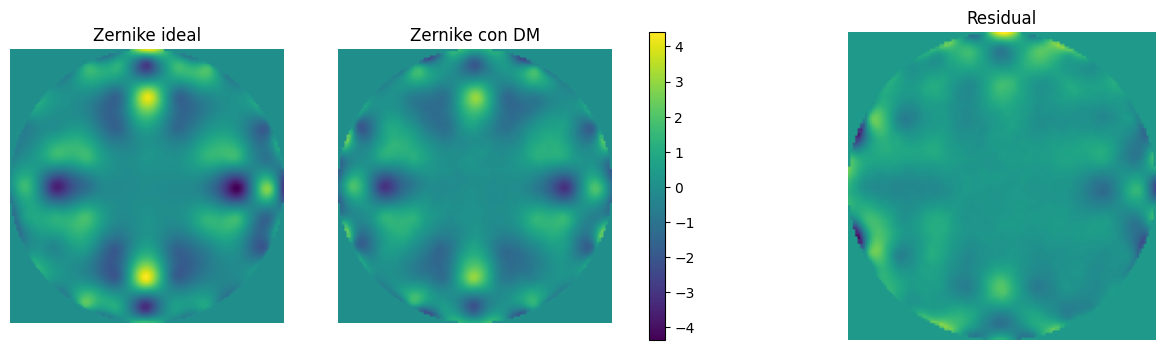

In [77]:
mode = 60

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

vmin = zComposeMat_OG[:, :, mode].min()
vmax = zComposeMat_OG[:, :, mode].max()

im = ax[0].imshow(
    zComposeMat_OG[:, :, mode].cpu(),
    vmin=vmin,
    vmax=vmax,
)
ax[0].set_title("Zernike ideal")

ax[1].imshow(
    zernike_dm[:, :, mode].cpu(),
    vmin=vmin,
    vmax=vmax,
)
ax[1].set_title("Zernike con DM")

error = (
    zComposeMat_OG[:, :, mode]
    - zernike_dm[:, :, mode]
)

ax[2].imshow(
    error.cpu()
)
ax[2].set_title("Residual")

for a in ax:
    a.axis("off")

plt.colorbar(im, ax=ax[:2])
plt.show()

In [82]:
errors = []

for mode in range(n_zernikes):

    ideal = zernike_ideal[:, :, mode][mask]
    dm = zComposeMat_OG[:, :, mode][mask]

    residual = ideal - dm

    rms = torch.std(residual)

    relative_rms = (
        torch.std(residual)
        / torch.std(ideal)
    )

    errors.append(relative_rms.item())

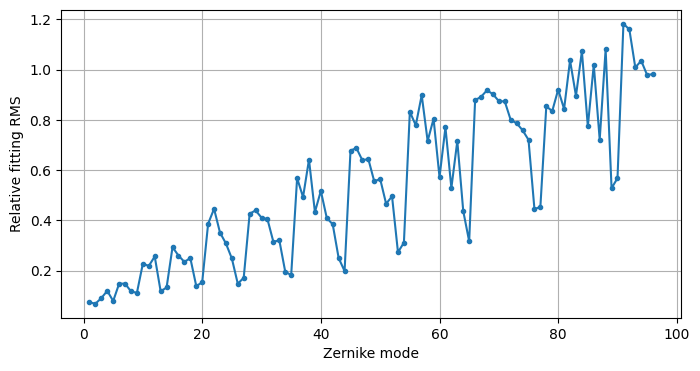

In [83]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, n_zernikes + 1),
    errors,
    ".-"
)

plt.xlabel("Zernike mode")
plt.ylabel("Relative fitting RMS")
plt.grid()

plt.show()